# The activity budget: distributions over cleavage patterns, not medians

## Scope

`4_01` computes the first cleavage exactly. A peptide in serum does not stop
there: the fragments are themselves substrates, and the molecule descends a
branching chain of states. The question this notebook answers is not *what
happens* to a peptide — there is no single answer — but **how wide the range of
outcomes is**, and whether the choice of activity transform changes the ordering
of peptides or only the units.

Three things are therefore done per peptide rather than once:

1. many trajectories, so the potency relative to the intact peptide is a
   **distribution over cleavage patterns** rather than one number;
2. many peptides per transform, spanning the potency range, so each transform is
   characterised by a distribution and not by a single value;
3. an explicit decomposition of where the remaining potency sits, for the most
   and least potent peptides in the probe, since those are the cases where the
   fragments behave least alike.

## The simulation

The process is a continuous-time Markov chain simulated by the Gillespie
construction: the waiting time to the next event is drawn from the exponential
distribution of the summed hazard, and the event that fires is drawn in
proportion to its own intensity. Event times are **exact**; no time step is
chosen, so none can be too coarse. Because cleavage is first order in the
peptide, molecules are independent and a population is the distribution over
repeated single-molecule trajectories.

## The minimum-length guard, taken from `4_03`

`4_03` tested the mixture rule against two digests of LL-37 whose activity
outcome is published. Counting every fragment, the digest that abolishes activity
is predicted $2.6\times$ *more* potent than the intact peptide, because a
four-residue product lies outside the MIC model's domain and still receives a
finite prediction. A minimum-length guard between $9$ and $21$ residues
reproduces both published digests. This notebook uses the lower edge of that
range and reports the sensitivity across it, rather than the guard of four that
the previous version of this notebook used.

## The time axis is provisional

`3_01` fitted the constant that puts the hazard in minutes and found that the
modelled hazard does not order measured degradation rates. Horizons below carry
the unit but not a demonstrated rate. Comparisons **between** peptides under one
weighting are unaffected by that constant; statements about absolute minutes are
not. `3_02` shows separately that the *bond ranking* inside a peptide is sound,
so the cleavage patterns explored here are better supported than their timing.

## Inputs and outputs

Inputs: `results/2_07_model_panel.csv`, `results/3_01_time_axis_calibration.csv`,
`data/merops/`, `data/reference/human_proteome/composition.json`, the APEX MIC
tables and the APEX ensemble for fragments the tables do not cover.

Outputs: `results/4_02_potency_distribution.csv`,
`results/4_02_transform_comparison.csv`, `results/4_02_guard_sensitivity.csv`,
`results/4_02_fragment_decomposition.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.activity import (
    activity_budget,
    activity_transform_registry,
    build_activity_transform,
)
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    Fragment,
    ProteaseKinetics,
    load_amino_acid_background,
    load_protease_panel,
    simulate_trajectory,
    state_at,
)
from pep_compass.optimization.components.oracles.strategies.apex.predictor import APEXPredictor

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
MIC_COLUMN = "A. baumannii ATCC 19606"
FRAGMENT_MIC_COLUMN = f"mic_{MIC_COLUMN}"
SCORE_SLOPE = 0.404 * np.log(10.0)
# REMARK: Twelve peptides in each of three potency tiers. The quantities reported
# are distributions, so the sample is sized to describe a tier rather than to
# resolve a difference between individual peptides.
N_PER_TIER = 12
N_TRAJECTORIES = 60
HORIZON_MINUTES = 480.0
N_TIME_POINTS = 97
MAX_EVENTS = 40
# REMARK: The transforms have thresholds at a potency sum of one, which is the
# definition of the MIC. Dosing at unit molar concentration would put every peptide
# two orders of magnitude below that threshold and silence half the registry, so
# the dose is expressed in multiples of the parent's own MIC and the intact peptide
# sits at exactly this value by construction.
DOSE_MULTIPLE = 1.0
# The guard range that reproduces both published digests in 4_03.
MIN_ACTIVE_LENGTH = 9
GUARD_SENSITIVITY = (9, 15, 21)
SEED = 20260920

In [3]:
rng = np.random.default_rng(SEED)
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
calibration = pd.read_csv(common.RESULTS_ROOT / "3_01_time_axis_calibration.csv")
times = np.linspace(0.0, HORIZON_MINUTES, N_TIME_POINTS)

print(f"transforms: {activity_transform_registry.names()}")
print(f"horizon {HORIZON_MINUTES:.0f} provisional minutes, {N_TRAJECTORIES} trajectories per peptide")
print(f"minimum active fragment length: {MIN_ACTIVE_LENGTH} residues (from 4_03)")

transforms: ('hill_kill_rate', 'log_potency', 'net_kill_rate', 'potency_sum', 'soft_threshold', 'threshold')
horizon 480 provisional minutes, 60 trajectories per peptide
minimum active fragment length: 9 residues (from 4_03)


## The probe: peptides spanning the potency range

A budget computed only on good peptides says nothing about whether the model
distinguishes good from bad. The probe is stratified by the predicted MIC of the
intact peptide into a potent tier, a middle tier and a weak tier, so every
distribution below can be read per tier and the extremes are present by
construction.

In [4]:
apex_table = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset", MIC_COLUMN])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .dropna(subset=[MIC_COLUMN])
    .drop_duplicates(subset=["sequence"])
)
## Keep lengths where the fragment tables and the panel are both meaningful
apex_table = apex_table[apex_table["sequence"].str.len().between(12, 30)].reset_index(drop=True)
ranked = apex_table.sort_values(MIC_COLUMN).reset_index(drop=True)
tier_slices = {
    "potent": ranked.head(N_PER_TIER * 4),
    "middle": ranked.iloc[len(ranked) // 2 - N_PER_TIER * 2 : len(ranked) // 2 + N_PER_TIER * 2],
    "weak": ranked.tail(N_PER_TIER * 4),
}
probe = pd.concat(
    [frame.sample(n=N_PER_TIER, random_state=SEED).assign(tier=tier) for tier, frame in tier_slices.items()]
).reset_index(drop=True)
print(probe.groupby("tier")[MIC_COLUMN].describe()[["min", "50%", "max"]].round(1).to_string())

          min    50%    max
tier                       
middle   61.9   63.2   63.9
potent    6.1    9.0   10.6
weak    136.7  138.9  148.0


## Fragment potencies, precomputed once

Every state a trajectory can reach is a set of contiguous subsequences of the
parent, so the complete set of fragments is known before any simulation runs.
Predicting them once turns the simulation into table lookups and makes the
trajectory count cheap.

In [5]:
fragment_table = pd.read_csv(
    common.DBAASP_FRAGMENTS_CSV, usecols=["fragment_sequence", FRAGMENT_MIC_COLUMN]
)
mic_of = dict(zip(fragment_table["fragment_sequence"], fragment_table[FRAGMENT_MIC_COLUMN]))

needed = {
    sequence[start:end]
    for sequence in probe["sequence"]
    for start in range(len(sequence))
    for end in range(start + MIN_ACTIVE_LENGTH, len(sequence) + 1)
}
missing = sorted(needed - set(mic_of))
print(f"distinct fragments at or above the guard: {len(needed):,} | not in the table: {len(missing):,}")

if missing:
    predictor = APEXPredictor(model="full", device="cpu")
    predicted = predictor.predict(missing)[:, 0]  # (N,)
    mic_of.update(dict(zip(missing, predicted)))
print(f"lookup covers {sum(1 for f in needed if f in mic_of):,} of {len(needed):,}")

distinct fragments at or above the guard: 1,550 | not in the table: 0
lookup covers 1,550 of 1,550


## The panel, and the state-to-potency map

A state is a set of contiguous fragments, each inheriting the molar concentration
of the parent. The potency sum is $\psi = \sum_i C_i / \mathrm{MIC}_i$ over the
fragments that pass the length guard, and the quantity reported throughout is
$\psi$ relative to the intact peptide, which removes the parent's own potency and
leaves only what cleavage did.

In [6]:
human_panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
matrices = human_panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(human_panel.codes)}
available = panel[panel["merops_code"].isin(index_of)].copy()
with_abundance = available.dropna(subset=["abundance_pg_per_l"]).copy()
alpha_of = dict(zip(calibration["weighting"], calibration["alpha"]))


def build(frame: pd.DataFrame, weights: np.ndarray, slope: float, intercept: float) -> ProteaseKinetics:
    """Assemble the panel for one weighting.

    :param frame: Panel rows to include.
    :param weights: Per-protease weight.
    :param slope: Score-to-log-intensity coefficient; zero switches the score off.
    :param intercept: Calibrated global offset.
    :return: The assembled kinetics.
    """

    return ProteaseKinetics(
        matrices=np.stack([matrices[index_of[code]] for code in frame["merops_code"]]),
        geometries=tuple(EventGeometry(value) for value in frame["event_geometry"]),
        weights=np.asarray(weights, dtype=float),
        codes=tuple(frame["merops_code"]),
        intercept=intercept,
        slope=slope,
    )


abundance_weights = (
    with_abundance["abundance_pg_per_l"] / with_abundance["abundance_pg_per_l"].median()
).to_numpy()
variants = {
    "concentration": build(with_abundance, abundance_weights, SCORE_SLOPE, alpha_of["concentration"]),
    "concentration_only": build(with_abundance, abundance_weights, 0.0, alpha_of["concentration"]),
}


def state_potency(
    parent: str, fragments: tuple[Fragment, ...], concentration: float, guard: int = MIN_ACTIVE_LENGTH
) -> float:
    """Return the potency sum of one state.

    :param parent: Parent peptide sequence.
    :param fragments: Fragments held in the state.
    :param concentration: Molar concentration each fragment inherits.
    :param guard: Minimum fragment length counted as active.
    :return: The potency sum, in multiples of the parent's own MIC.
    """

    total = 0.0
    for fragment in fragments:
        piece = parent[fragment.start : fragment.end]
        if len(piece) < guard:
            continue
        mic = mic_of.get(piece)
        if mic is not None and mic > 0:
            total += concentration / float(mic)
    return total


def dose_for(parent: str) -> float:
    """Return the molar dose that places the intact peptide at ``DOSE_MULTIPLE``.

    :param parent: Parent peptide sequence.
    :return: The concentration to give every fragment of this parent.
    """

    return DOSE_MULTIPLE * float(mic_of[parent])

## Simulating, and keeping every trajectory

The previous version of this notebook averaged trajectories before reporting,
which hid the only interesting feature of the process: two molecules of the same
peptide can follow very different cleavage patterns and end in states of very
different potency. Each trajectory is therefore kept as its own row.

In [7]:
records = []
decomposition = []
for _, row in probe.iterrows():
    parent = row["sequence"]
    dose = dose_for(parent)
    intact = state_potency(parent, (Fragment(0, len(parent)),), dose)
    for weighting, kinetics in variants.items():
        for replicate in range(N_TRAJECTORIES):
            steps = simulate_trajectory(
                parent,
                kinetics,
                np.random.default_rng(rng.integers(0, 2**32 - 1)),
                HORIZON_MINUTES,
                human_background,
                max_events=MAX_EVENTS,
            )
            ## Potency on a fixed grid, so trajectories with different event counts align
            potency = np.array([state_potency(parent, state_at(steps, time), dose) for time in times])
            final_state = state_at(steps, HORIZON_MINUTES)
            n_events = max(len(steps) - 1, 0)
            records.append(
                {
                    "sequence": parent,
                    "tier": row["tier"],
                    "length": len(parent),
                    "parent_mic": row[MIC_COLUMN],
                    "weighting": weighting,
                    "replicate": replicate,
                    "n_events": n_events,
                    "n_fragments_at_horizon": len(final_state),
                    "relative_potency_at_horizon": potency[-1] / intact if intact > 0 else np.nan,
                    "min_relative_potency": potency.min() / intact if intact > 0 else np.nan,
                    "potency_curve": potency.tolist(),
                    "intact_potency": intact,
                }
            )
            ## Fragment-level bookkeeping, used for the extreme peptides below
            if weighting == "concentration":
                for fragment in final_state:
                    piece = parent[fragment.start : fragment.end]
                    mic = mic_of.get(piece) if len(piece) >= MIN_ACTIVE_LENGTH else None
                    decomposition.append(
                        {
                            "sequence": parent,
                            "tier": row["tier"],
                            "replicate": replicate,
                            "span": f"{fragment.start + 1}-{fragment.end}",
                            "fragment_length": len(piece),
                            "counted": mic is not None,
                            "potency_contribution": dose / float(mic) if mic else 0.0,
                            "intact_potency": intact,
                        }
                    )

trajectories = pd.DataFrame(records)
fragment_frame = pd.DataFrame(decomposition)
trajectories["reaches_zero"] = trajectories["relative_potency_at_horizon"] == 0.0
main_summary = trajectories[trajectories["weighting"] == "concentration"]
print(f"trajectories: {len(trajectories):,} | fragment rows: {len(fragment_frame):,}")
print(
    main_summary.groupby("tier")["relative_potency_at_horizon"]
    .describe()[["mean", "std", "min", "50%", "max"]]
    .round(3)
    .to_string()
)

# REMARK: A ratio of the extremes is undefined here, because a trajectory whose
# fragments all fall below the guard has exactly zero potency. The spread is
# therefore the interdecile range, and the mass at zero is reported separately.
spread = main_summary.groupby("sequence")["relative_potency_at_horizon"].agg(
    p10=lambda values: float(np.percentile(values, 10)),
    p90=lambda values: float(np.percentile(values, 90)),
    zero_fraction=lambda values: float(np.mean(values == 0.0)),
)
spread["interdecile_range"] = spread["p90"] - spread["p10"]
print("\nspread over cleavage patterns, per peptide:")
print(spread[["interdecile_range", "zero_fraction"]].describe().loc[["min", "50%", "max"]].round(3).to_string())
print(
    f"peptides whose interdecile range exceeds half the intact potency: "
    f"{int((spread['interdecile_range'] > 0.5).sum())} of {len(spread)}"
)

trajectories: 4,320 | fragment rows: 6,635
         mean    std  min    50%    max
tier                                   
middle  0.330  0.366  0.0  0.000  1.130
potent  0.269  0.365  0.0  0.115  1.276
weak    0.688  0.578  0.0  1.000  2.071

spread over cleavage patterns, per peptide:
     interdecile_range  zero_fraction
min              0.000           0.00
50%              0.677           0.35
max              1.130           1.00
peptides whose interdecile range exceeds half the intact potency: 21 of 36


### Reading the figure

Each row of points is one peptide; each point is one trajectory, so the spread
along the horizontal axis is the spread over cleavage patterns of the *same*
molecule. The dashed line at $1$ is the intact peptide. A peptide whose points
form a tight cluster has a cleavage outcome that barely depends on which bond
fires first; a peptide whose points spread over an order of magnitude does not,
and for it a single expected value is not a useful summary.

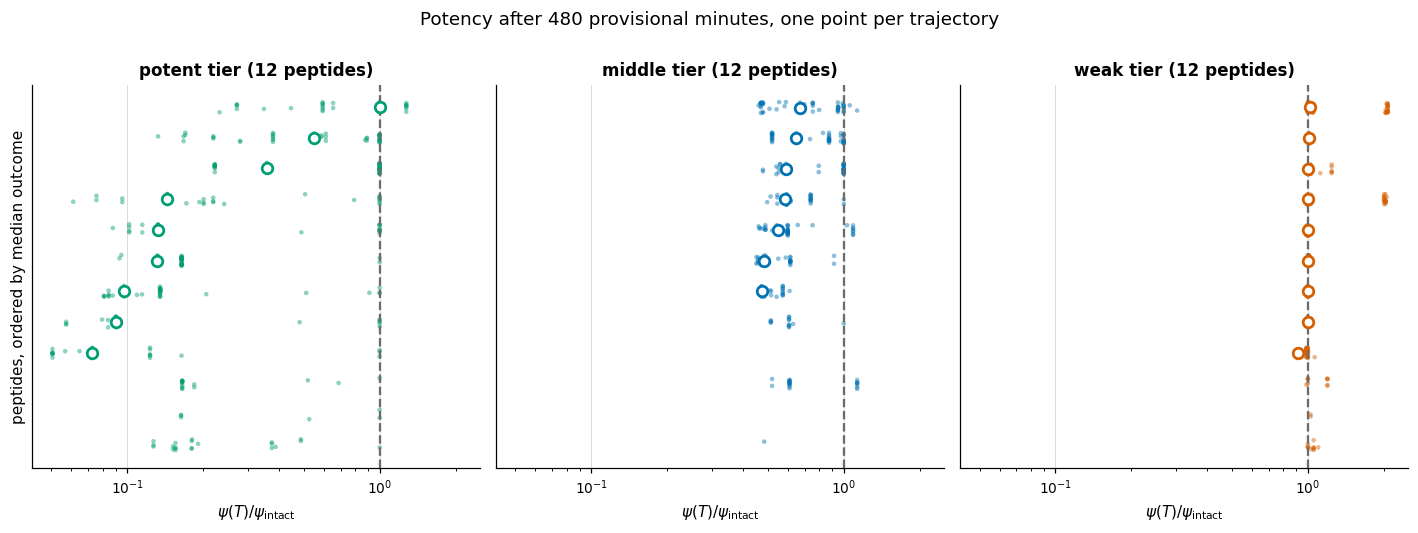

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.8), sharex=True)
main = trajectories[trajectories["weighting"] == "concentration"]
for ax, (tier, colour) in zip(
    axes, zip(("potent", "middle", "weak"), (common.CATEGORICAL_COLORS[2], common.CATEGORICAL_COLORS[0], common.CATEGORICAL_COLORS[1]))
):
    subset = main[main["tier"] == tier]
    sequences = subset.groupby("sequence")["relative_potency_at_horizon"].median().sort_values().index
    for position, sequence in enumerate(sequences):
        values = subset.loc[subset["sequence"] == sequence, "relative_potency_at_horizon"].to_numpy()
        ax.scatter(
            values,
            np.full(len(values), position) + rng.uniform(-0.18, 0.18, len(values)),
            s=9,
            color=colour,
            alpha=0.45,
            edgecolor="none",
        )
        ax.scatter(np.median(values), position, s=48, color="white", edgecolor=colour, linewidth=1.8, zorder=4)
    ax.axvline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
    ax.set_yticks([])
    ax.set_xscale("log")
    ax.set_xlabel(r"$\psi(T) / \psi_{\mathrm{intact}}$")
    ax.set_title(f"{tier} tier ({len(sequences)} peptides)")
axes[0].set_ylabel("peptides, ordered by median outcome")
fig.suptitle(f"Potency after {HORIZON_MINUTES:.0f} provisional minutes, one point per trajectory", y=1.0)
fig.tight_layout()
plt.show()

## Every transform, over every peptide

The budget $B(T) = \int_0^T A(t)\,\mathrm{d}t$ depends on the transform that
turns the potency sum into an activity. Each registered transform is applied to
the same trajectories and reported as the mean activity $B(T)/T$, together with
the activity the intact peptide would hold for the whole horizon.

The two are reported side by side rather than as a ratio. Two of the registered
transforms are signed — `log_potency` is negative below the MIC and
`net_kill_rate` is negative while growth outpaces killing — and dividing a
negative budget by a negative reference inverts the direction of the objective,
turning a peptide that lost all activity into one with the largest ratio. A
third, `threshold`, is zero for the intact peptide at a dose of one MIC, so a
ratio is undefined for it. The mean activity is comparable across all six.

Each transform therefore receives a distribution over the full probe rather than
a single number, and the ordering comparison is made on the mean activity, where
larger is better for every transform in the registry.

In [9]:
transform_records = []
curves = np.stack(main["potency_curve"].to_numpy())  # (R, T)
intact_values = main["intact_potency"].to_numpy()  # (R,)
for name in activity_transform_registry.names():
    transform = build_activity_transform(name)
    activity = np.array([transform(curve) for curve in curves])  # (R, T)
    ## The intact peptide holds its activity for the whole horizon by definition
    intact_activity = np.array([float(transform(np.array([value]))[0]) for value in intact_values])  # (R,)
    for position, (_, row) in enumerate(main.iterrows()):
        budget = activity_budget(times, activity[position])
        transform_records.append(
            {
                "sequence": row["sequence"],
                "tier": row["tier"],
                "replicate": row["replicate"],
                "transform": name,
                "budget": budget,
                "mean_activity": budget / HORIZON_MINUTES,
                "intact_activity": float(intact_activity[position]),
                "activity_lost": float(intact_activity[position]) - budget / HORIZON_MINUTES,
            }
        )

transform_frame = pd.DataFrame(transform_records)
per_peptide = (
    transform_frame.groupby(["transform", "sequence", "tier"])[["mean_activity", "intact_activity", "activity_lost"]]
    .mean()
    .reset_index()
)
print(
    per_peptide.groupby("transform")[["intact_activity", "mean_activity", "activity_lost"]]
    .describe()
    .loc[:, (slice(None), ["mean", "min", "max"])]
    .round(3)
    .to_string()
)

## Do the transforms order the peptides the same way?
ordering = per_peptide.pivot(index="sequence", columns="transform", values="mean_activity")
agreement = ordering.corr(method="spearman")
print("\nSpearman agreement between transforms, on mean activity:")
print(agreement.round(3).to_string())

               intact_activity           mean_activity                activity_lost               
                          mean  min  max          mean     min    max          mean    min     max
transform                                                                                         
hill_kill_rate             0.5  0.5  0.5         0.324   0.086  0.542         0.176 -0.042   0.414
log_potency                0.0  0.0  0.0        -5.082 -16.062  0.238         5.082 -0.238  16.062
net_kill_rate              0.0  0.0  0.0        -0.176  -0.414  0.042         0.176 -0.042   0.414
potency_sum                1.0  1.0  1.0         0.624   0.158  1.255         0.376 -0.255   0.842
soft_threshold             0.5  0.5  0.5         0.324   0.086  0.542         0.176 -0.042   0.414
threshold                  1.0  1.0  1.0         0.479   0.089  0.999         0.521  0.001   0.911

Spearman agreement between transforms, on mean activity:
transform       hill_kill_rate  log_potency  net_ki

### Reading the figure

The left panel gives each transform its own distribution over the probe, split by
tier: a transform that collapses the tiers onto each other cannot serve as a
design objective, whatever its behaviour on a single peptide. The right panel is
the rank agreement between transforms; values near $1$ mean the choice of
transform changes the numbers but not the ranking.

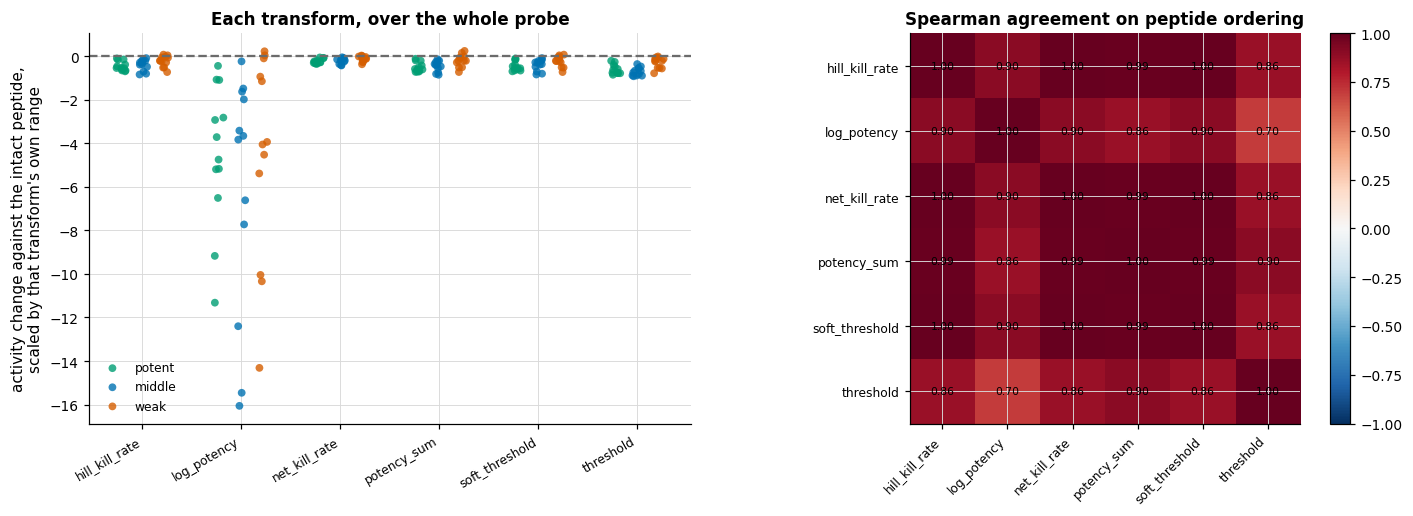

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

## Relative budget per transform, by tier
ax = axes[0]
names = list(activity_transform_registry.names())
tier_colour = {
    "potent": common.CATEGORICAL_COLORS[2],
    "middle": common.CATEGORICAL_COLORS[0],
    "weak": common.CATEGORICAL_COLORS[1],
}
## Each transform is on its own scale, so the axis is the fraction of the intact
## peptide's activity that the trajectory retained, which is defined for all six
for position, name in enumerate(names):
    subset = per_peptide[per_peptide["transform"] == name]
    span = subset["intact_activity"].abs().max()
    for offset, tier in enumerate(("potent", "middle", "weak")):
        rows = subset[subset["tier"] == tier]
        values = (rows["mean_activity"] - rows["intact_activity"]) / (span if span else 1.0)
        ax.scatter(
            np.full(len(values), position) + (offset - 1) * 0.22 + rng.uniform(-0.05, 0.05, len(values)),
            values,
            s=26,
            color=tier_colour[tier],
            alpha=0.8,
            edgecolor="none",
            label=tier if position == 0 else None,
        )
ax.axhline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("activity change against the intact peptide,\nscaled by that transform's own range")
ax.set_title("Each transform, over the whole probe")
ax.legend(frameon=False, fontsize=8)

## Rank agreement between transforms
ax = axes[1]
image = ax.imshow(agreement.to_numpy(), vmin=-1, vmax=1, cmap=common.DIVERGING_CMAP)
ax.set_xticks(range(len(agreement)))
ax.set_xticklabels(agreement.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(agreement)))
ax.set_yticklabels(agreement.index, fontsize=8)
for i in range(len(agreement)):
    for j in range(len(agreement)):
        ax.text(j, i, f"{agreement.to_numpy()[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Spearman agreement on peptide ordering")
fig.colorbar(image, ax=ax, fraction=0.046)

fig.tight_layout()
plt.show()

## Where the remaining potency sits, for the extremes

The relative potency is a sum over fragments, and the sum hides whether it is
carried by one large survivor or spread across several pieces. For the most and
the least potent peptide in the probe, every fragment present at the horizon is
accumulated over trajectories and ranked by how much of the total potency it
contributes. Fragments below the length guard are counted separately, as mass the
model refuses to score rather than as zero activity.

 span  fragment_length  counted    sum  size  share_of_intact  occurrence      peptide       sequence
 1-10               10     True 21.501    21            0.358       0.350 least potent VQNQHGQVVKIFHH
 6-14                9     True  6.213     5            0.104       0.083 least potent VQNQHGQVVKIFHH
 1-14               14     True  2.000     2            0.033       0.033 least potent VQNQHGQVVKIFHH
 5-14               10     True  1.121     1            0.019       0.017 least potent VQNQHGQVVKIFHH
 3-14               12     True  1.040     1            0.017       0.017 least potent VQNQHGQVVKIFHH
 2-10                9     True  1.006     1            0.017       0.017 least potent VQNQHGQVVKIFHH
 1-13               13     True  1.002     1            0.017       0.017 least potent VQNQHGQVVKIFHH
  1-1                1    False  0.000     3            0.000       0.050 least potent VQNQHGQVVKIFHH
  1-2                2    False  0.000     6            0.000       0.100 least po

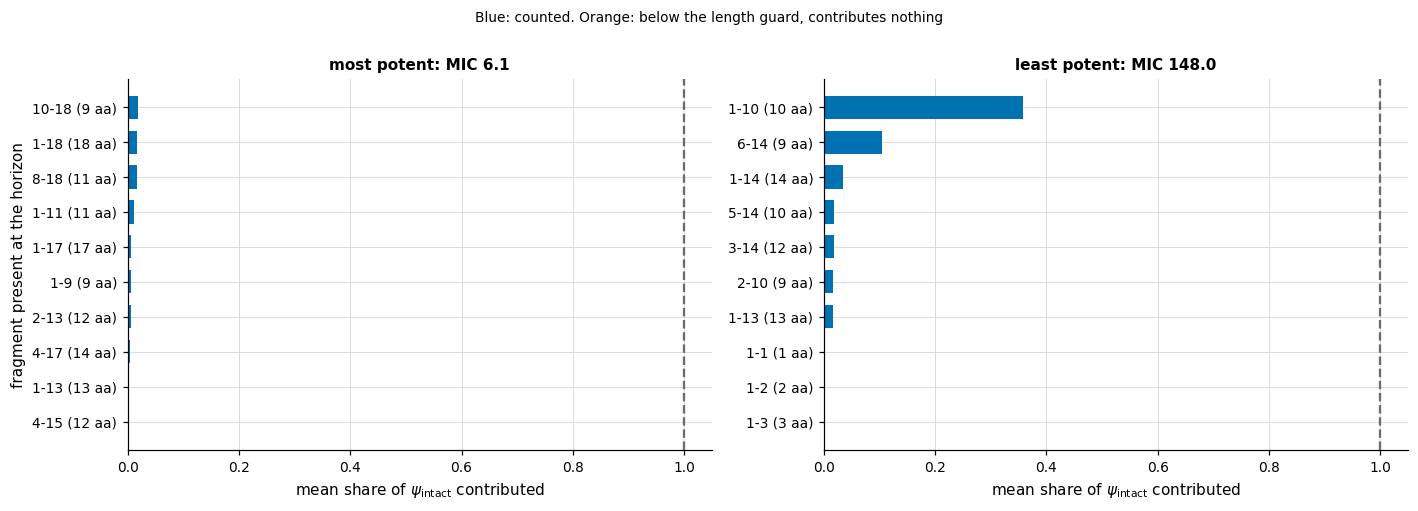

In [11]:
extreme_sequences = {
    "most potent": probe.loc[probe[MIC_COLUMN].idxmin(), "sequence"],
    "least potent": probe.loc[probe[MIC_COLUMN].idxmax(), "sequence"],
}
extreme_records = []
for label, sequence in extreme_sequences.items():
    subset = fragment_frame[fragment_frame["sequence"] == sequence]
    intact = subset["intact_potency"].iloc[0]
    grouped = (
        subset.groupby(["span", "fragment_length", "counted"])["potency_contribution"]
        .agg(["sum", "size"])
        .reset_index()
    )
    grouped["share_of_intact"] = grouped["sum"] / (intact * N_TRAJECTORIES)
    grouped["occurrence"] = grouped["size"] / N_TRAJECTORIES
    grouped["peptide"] = label
    grouped["sequence"] = sequence
    extreme_records.append(grouped)
extremes = pd.concat(extreme_records).sort_values(["peptide", "share_of_intact"], ascending=[True, False])
print(extremes.head(16).round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
for ax, (label, sequence) in zip(axes, extreme_sequences.items()):
    subset = extremes[extremes["peptide"] == label].head(10)
    colours = [
        common.CATEGORICAL_COLORS[0] if counted else common.CATEGORICAL_COLORS[3]
        for counted in subset["counted"]
    ]
    ax.barh(
        [f"{span} ({length} aa)" for span, length in zip(subset["span"], subset["fragment_length"])],
        subset["share_of_intact"],
        color=colours,
        height=0.66,
    )
    ax.axvline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
    ax.invert_yaxis()
    ax.set_xlabel(r"mean share of $\psi_{\mathrm{intact}}$ contributed")
    ax.set_title(f"{label}: MIC {probe.loc[probe['sequence'] == sequence, MIC_COLUMN].iloc[0]:.1f}", fontsize=10)
axes[0].set_ylabel("fragment present at the horizon")
fig.suptitle("Blue: counted. Orange: below the length guard, contributes nothing", y=1.0, fontsize=9)
fig.tight_layout()
plt.show()

## How much of this depends on the guard

The guard is the one free parameter introduced here, and `4_03` constrains it
only to a range. The final state of every trajectory is re-scored at the two ends
of that range and at its midpoint.

In [12]:
guard_records = []
for guard in GUARD_SENSITIVITY:
    needed_at_guard = {
        sequence[start:end]
        for sequence in probe["sequence"]
        for start in range(len(sequence))
        for end in range(start + guard, len(sequence) + 1)
    }
    unresolved = sorted(needed_at_guard - set(mic_of))
    if unresolved:
        mic_of.update(dict(zip(unresolved, APEXPredictor(model="full", device="cpu").predict(unresolved)[:, 0])))
    for sequence, group in fragment_frame.groupby("sequence"):
        dose = dose_for(sequence)
        intact = state_potency(sequence, (Fragment(0, len(sequence)),), dose, guard=1)
        kept = group[group["fragment_length"] >= guard]
        total = sum(
            dose / float(mic_of[sequence[int(span.split("-")[0]) - 1 : int(span.split("-")[1])]])
            for span in kept["span"]
        )
        guard_records.append(
            {
                "minimum_active_length": guard,
                "sequence": sequence,
                "tier": group["tier"].iloc[0],
                "mean_relative_potency": total / (intact * N_TRAJECTORIES),
            }
        )
guard_frame = pd.DataFrame(guard_records)
print(guard_frame.groupby(["minimum_active_length", "tier"])["mean_relative_potency"].median().unstack().round(3).to_string())

tier                   middle  potent   weak
minimum_active_length                       
9                       0.348   0.151  0.629
15                      0.000   0.028  0.000
21                      0.000   0.000  0.000


In [13]:
common.save_result(trajectories.drop(columns=["potency_curve"]), "4_02_potency_distribution.csv")
common.save_result(transform_frame, "4_02_transform_comparison.csv")
common.save_result(guard_frame, "4_02_guard_sensitivity.csv")
common.save_result(extremes, "4_02_fragment_decomposition.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/4_02_fragment_decomposition.csv')

## What this establishes

**The outcome of cleavage is a distribution, and for most peptides it is a wide
one.** The median peptide in the probe has an interdecile range of $0.68$ in
$\psi(T)/\psi_{\mathrm{intact}}$ — two thirds of the intact peptide's own potency
separating its tenth and ninetieth percentile outcome — and $21$ of $36$ peptides
exceed half. The median peptide also ends $35\%$ of its trajectories at exactly
zero, meaning every surviving fragment fell below the length guard. Reporting a
median for such a peptide discards the property that matters for design, which is
the weight of the bad branch, not the location of the middle one.

**The tiers separate, but in the direction that is bad for design.** Potent
peptides retain a median of $0.115$ of their potency at the horizon; weak peptides
retain $1.000$. The reason is arithmetic rather than biological: a potent parent
has a large $1/\mathrm{MIC}$, its fragments do not, and so it has more to lose. A
budget objective built naively on this quantity would prefer weak peptides, and
must be defined as activity retained *above a useful absolute level* rather than
as a fraction of the parent.

**Five of the six transforms order the peptides almost identically.**
`hill_kill_rate`, `net_kill_rate` and `soft_threshold` agree at Spearman $1.000$ —
they are monotone reparametrisations of each other over the range the probe
explores — and both agree with `potency_sum` at $0.989$. `log_potency` sits at
$0.86$ to $0.90$. Only `threshold` differs materially, $0.70$ to $0.90$, and it is
also the transform that collapses the potent and middle tiers onto each other
($0.318$ against $0.299$) while separating the weak one. For ranking purposes the
choice among the first five changes the units and not the selection; `threshold`
is a different objective and the only one where the choice is substantive.

**The remaining potency is carried by one fragment in the weak case and by nothing
in particular in the potent case.** The least potent peptide retains $0.565$ of the
parent's potency, of which a single ten-residue fragment carries $0.358$. The most
potent peptide retains $0.095$ spread over $48$ distinct fragment spans, none
contributing more than $0.019$. The decomposition is where that difference is
visible; the summary statistic is not.

**The length guard does not transfer from `4_03`.** The guard range of $9$ to $21$
residues was calibrated on LL-37, a $37$-residue peptide. On a probe of $12$ to
$30$ residues, a guard of $15$ already drives the median retained potency of two
tiers to zero and $21$ drives all three. An absolute minimum length is therefore
the wrong form for the constraint: it must scale with the parent, or the domain of
the MIC model has to be bounded some other way. Everything reported above uses the
lower edge, $9$ residues, and the sensitivity table is the evidence that the upper
edge is unusable here.

**Limits.** The dose is one MIC of the parent, which fixes where the thresholded
transforms operate; a different dose would move `threshold` and `soft_threshold`
and leave the others' ordering intact. The horizon is in provisional minutes, since
`3_01` did not validate the rate, though `3_02` supports the bond ranking that
generates the cleavage patterns. The probe is thirty-six peptides from one dataset
and one strain, and the tiers are defined by the same MIC model whose fragment
predictions are being summed, so the tier labels are not independent of the
quantity measured.